In this script, we create an illustration for the calulation of variance and mean for the stochatic damped harmonic oscillator.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

torch.set_default_dtype(torch.float64)
import scipy
import os
import math
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

plt.rcParams.update({
    "text.usetex": True,  # Enable LaTeX rendering
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"], # Specify the font (classic LaTeX font)
    # You might need to adjust the font paths or preamble depending on your setup
    # "text.latex.preamble": r"\usepackage{amsmath}" # Example if you need math packages
})

In [2]:
# Simulation parameters.
T = 40.0                         # Total simulation time.
omega0 = math.sqrt(1.0)                   # Fundamental frequency
zeta = 0.5                      # Damping ratio
temp = 1.0                     # Temperature (similar to sigma ** 2)

if zeta < 1.0:
    dt = 0.001 / (omega0 * max(zeta, math.sqrt(1 - zeta**2)))  
elif zeta == 1.0:
    dt = 0.001 / omega0
else:
    dt = 0.001 / (omega0 * max(zeta + math.sqrt(zeta**2 - 1), zeta - math.sqrt(zeta**2 - 1)))

# define the level u
u = 1.0

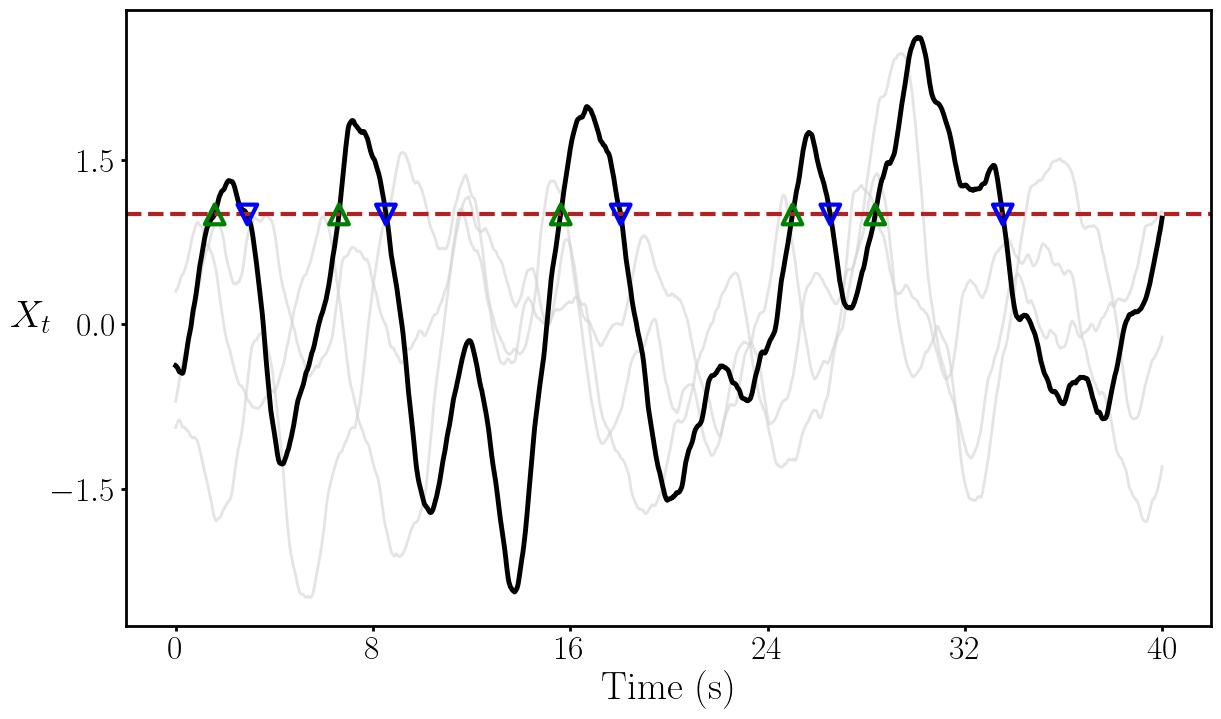

In [3]:
num_x_ticks = 6  # Desired number of ticks on the x-axis
num_y_ticks = 5  # Desired number of ticks on the y-axis
axis_label_fontsize = 28 # Fontsize for x and y labels
tick_label_fontsize = 24 # Fontsize for tick labels
tick_line_width = 2.0    # Thickness of tick lines
spine_line_width = 2.0   # Thickness of plot border

# Generate 5 background simulations and plot them in gray
plt.figure(figsize=(14, 8))
ax = plt.gca() # Get the current axes instance for easier manipulation

num_bg_samples = 3
for _ in range(num_bg_samples):
    t_bg, x_bg = utils.simulate_gaussian_process_fft( # Renamed t to t_bg to avoid reuse
        process.r_damped_harmonic_oscillator_noise, T, dt, temp=temp, omega0=omega0, zeta=zeta
    )
    ax.plot(t_bg, x_bg, color='lightgray', alpha=0.6, linewidth=2)

# Main trajectory
t, x = utils.simulate_gaussian_process_fft(
    process.r_damped_harmonic_oscillator_noise, T, dt, temp=temp, omega0=omega0, zeta=zeta
)
times, directions = utils.crossing_times(x, t=t, threshold=u)

# Plot the main trajectory with thicker line
ax.plot(t, x, label='Main sample', color='black', linewidth=3.5) # Label kept for potential future use

# Plot the threshold line
ax.axhline(y=u, color='firebrick', linestyle='--', label='Threshold', linewidth=3) # Label kept for potential future use

# Upcrossings and downcrossings
up_times = times[directions > 0]
down_times = times[directions < 0]
up_marker_height = u * np.ones_like(up_times)
down_marker_height = u * np.ones_like(down_times)

# Markers
ax.scatter(up_times, up_marker_height, color='green', facecolors='none', edgecolors='green', linewidths=3, marker='^', s=200, label='Upcrossings', zorder=4) # Label kept
ax.scatter(down_times, down_marker_height, color='blue', facecolors='none', edgecolors='blue', marker='v', linewidths=3, s=200, label='Downcrossings', zorder=4) # Label kept

# set number of ticks on x and y axes
ax.xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
ax.yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))


# --- Labels and Appearance Adjustments ---
# Labels with larger fonts (using LaTeX)
ax.set_xlabel(r'Time (s)', fontsize=axis_label_fontsize)
# Set Y label, rotate it horizontally, adjust padding and vertical alignment
ax.set_ylabel(r'$X_t$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=15)

# Increase tick label font size AND make tick LINES thicker
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)
# You can also adjust minor ticks if they are visible/enabled:
# ax.tick_params(axis='both', which='minor', width=tick_line_width*0.6)

# Make the plot border (spines) thicker
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)
# --- End Appearance Adjustments ---

# --- Remove Legend ---
# ax.legend(fontsize=18) # Legend is removed by commenting this out
# --- End Remove Legend ---

folder_loc = f'../figures/fig1'
os.makedirs(folder_loc, exist_ok=True)
file_name = f'trajectories_latex_custom' # Changed filename slightly
file_save_path = os.path.join(folder_loc, file_name)

# Important: bbox_inches='tight' is good practice, especially with LaTeX
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
# plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

# Layout (often less critical when bbox_inches='tight' is used for saving)
# plt.tight_layout() # Can sometimes conflict with LaTeX, try with/without if layout issues arise
plt.show()